Generation 0: Best Fitness = 192.08
Generation 3: Best Fitness = 181.08
Generation 6: Best Fitness = 174.06
Generation 8: Best Fitness = 169.31
Generation 9: Best Fitness = 157.53
Generation 10: Best Fitness = 126.85
Generation 12: Best Fitness = 91.91
Generation 13: Best Fitness = 87.07
Generation 22: Best Fitness = 85.90
Generation 23: Best Fitness = 79.00
Generation 28: Best Fitness = 76.39
Generation 31: Best Fitness = 58.91
Generation 35: Best Fitness = 47.85
Generation 38: Best Fitness = 46.49
Generation 39: Best Fitness = 45.59
Generation 40: Best Fitness = 39.84
Generation 48: Best Fitness = 38.71
Generation 51: Best Fitness = 36.23
Generation 54: Best Fitness = 31.62
Generation 56: Best Fitness = 28.42
Generation 58: Best Fitness = 27.38
Generation 59: Best Fitness = 25.64
Generation 60: Best Fitness = 23.98
Generation 61: Best Fitness = 21.03
Generation 64: Best Fitness = 20.11
Generation 66: Best Fitness = 16.70
Generation 69: Best Fitness = 16.52
Generation 71: Best Fitness

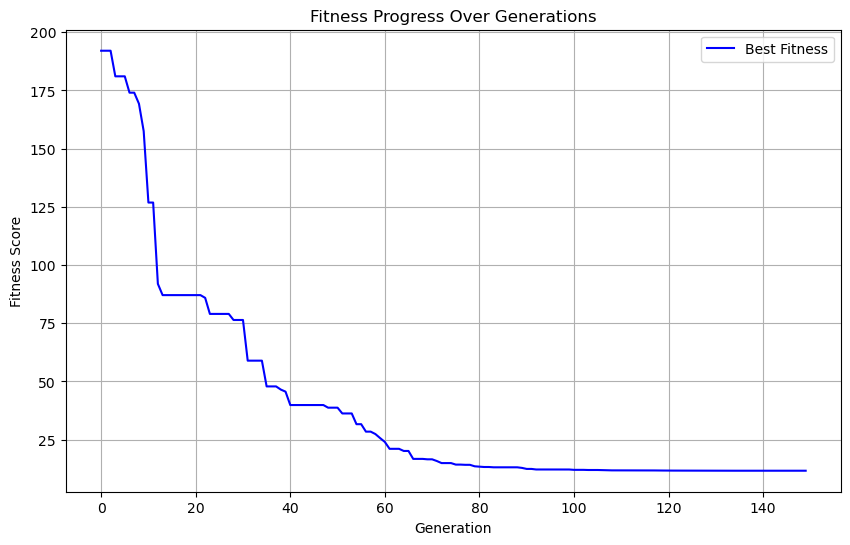

In [15]:
import random
import string
from collections import defaultdict
import matplotlib.pyplot as plt

def process_reference(file_path):
    """Process the reference text to compute letter frequencies."""
    letter_counts = defaultdict(int)
    total = 0
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            for c in line:
                if c.isalpha():
                    upper_c = c.upper()
                    letter_counts[upper_c] += 1
                    total += 1
    p = [0.0] * 26
    for i in range(26):
        letter = chr(ord('A') + i)
        count = letter_counts.get(letter, 0)
        p[i] = (count / total) * 100 if total > 0 else 0
    return p

def process_ciphertext(file_path):
    """Process the ciphertext to compute letter counts."""
    cipher_counts = [0] * 26
    total_letters = 0
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            for c in line:
                if c.isalpha():
                    upper_c = c.upper()
                    idx = ord(upper_c) - ord('A')
                    cipher_counts[idx] += 1
                    total_letters += 1
    return cipher_counts, total_letters

def calculate_fitness(key, cipher_counts, total_letters, p):
    """Calculate the fitness of a key based on letter frequencies."""
    letter_counts = [0] * 26
    for cipher_idx in range(26):
        plain_char = key[cipher_idx]
        plain_idx = ord(plain_char) - ord('A')
        letter_counts[plain_idx] += cipher_counts[cipher_idx]
    F = 0.0
    for i in range(26):
        actual = (letter_counts[i] / total_letters) * 100 if total_letters > 0 else 0
        expected = p[i]
        F += (actual - expected) ** 2
    return F

def generate_individual():
    """Generate a random permutation of the alphabet."""
    letters = list(string.ascii_uppercase)
    random.shuffle(letters)
    return letters

def tournament_selection(population, fitness_scores, tournament_size):
    """Select a parent using tournament selection."""
    selected_indices = random.sample(range(len(population)), tournament_size)
    best_index = selected_indices[0]
    best_score = fitness_scores[best_index]
    for idx in selected_indices[1:]:
        if fitness_scores[idx] < best_score:
            best_score = fitness_scores[idx]
            best_index = idx
    return population[best_index]

def crossover(parent1, parent2):
    """Perform order crossover between two parents."""
    size = len(parent1)
    start = random.randint(0, size - 1)
    end = random.randint(start, size - 1)
    child = [None] * size
    for i in range(start, end + 1):
        child[i] = parent1[i]
    current_pos = 0
    for gene in parent2:
        if gene not in child[start:end + 1]:
            while current_pos < size:
                if (current_pos < start or current_pos > end) and child[current_pos] is None:
                    child[current_pos] = gene
                    current_pos += 1
                    break
                else:
                    current_pos += 1
    remaining_genes = [g for g in parent2 if g not in child]
    for i in range(size):
        if child[i] is None:
            if remaining_genes:
                child[i] = remaining_genes.pop(0)
    return child

def mutate(individual, mutation_rate):
    """Mutate an individual by swapping two genes."""
    if random.random() < mutation_rate:
        i = random.randint(0, 25)
        j = random.randint(0, 25)
        while i == j:
            j = random.randint(0, 25)
        individual[i], individual[j] = individual[j], individual[i]
    return individual

def genetic_algorithm(cipher_counts, total_letters, p, params, stagnation_limit=100):
    """Run the genetic algorithm to find the best key and plot fitness progress."""
    population_size = params['population_size']
    generations = params['generations']
    mutation_rate = params['mutation_rate']
    tournament_size = params['tournament_size']
    elitism = params['elitism']

    population = [generate_individual() for _ in range(population_size)]
    best_individual = None
    best_fitness = float('inf')
    fitness_history = []
    stagnation = 0

    for gen in range(generations):
        fitness_scores = [calculate_fitness(ind, cipher_counts, total_letters, p) for ind in population]
        current_best_fitness = min(fitness_scores)
        current_best_index = fitness_scores.index(current_best_fitness)
        current_best = population[current_best_index]

        fitness_history.append(current_best_fitness)
        if current_best_fitness < best_fitness:
            best_fitness = current_best_fitness
            best_individual = current_best.copy()
            print(f"Generation {gen}: Best Fitness = {best_fitness:.2f}")
        else:
            stagnation += 1

        if stagnation >= stagnation_limit:
            break

        new_population = []
        sorted_population = [ind for _, ind in sorted(zip(fitness_scores, population), key=lambda x: x[0])]
        new_population.extend(sorted_population[:elitism])

        while len(new_population) < population_size:
            parent1 = tournament_selection(population, fitness_scores, tournament_size)
            parent2 = tournament_selection(population, fitness_scores, tournament_size)
            child = crossover(parent1, parent2)
            child = mutate(child, mutation_rate)
            new_population.append(child)

        population = new_population

    # Plot fitness history
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(fitness_history)), fitness_history, 'b-', label='Best Fitness')
    plt.title('Fitness Progress Over Generations')
    plt.xlabel('Generation')
    plt.ylabel('Fitness Score')
    plt.grid(True)
    plt.legend()
    plt.savefig('fitness_plot.png')

    return best_individual

def decrypt_file(ciphertext_file, best_individual, output_file):
    """Decrypt the ciphertext using the best key."""
    with open(ciphertext_file, 'r', encoding='utf-8') as f_in, open(output_file, 'w', encoding='utf-8') as f_out:
        for line in f_in:
            decrypted_line = []
            for c in line:
                if c.isalpha():
                    is_upper = c.isupper()
                    cipher_idx = ord(c.upper()) - ord('A')
                    plain_char = best_individual[cipher_idx]
                    if not is_upper:
                        plain_char = plain_char.lower()
                    decrypted_line.append(plain_char)
                else:
                    decrypted_line.append(c)
            f_out.write(''.join(decrypted_line))

def write_key(best_individual, key_file):
    """Write the decryption key to a file."""
    ciphertext_letters = []
    for plain_char in string.ascii_uppercase:
        index = best_individual.index(plain_char)
        ciphertext_char = chr(ord('A') + index)
        ciphertext_letters.append(ciphertext_char.lower())
    with open(key_file, 'w', encoding='utf-8') as f:
        f.write('plaintext: ' + ', '.join(string.ascii_lowercase) + '\n')
        f.write('cyphertext: ' + ', '.join(ciphertext_letters) + '\n')

def main():
    # Define parameters
    params = {
        'population_size': 1000,
        'generations': 500,
        'mutation_rate': 0.1,
        'tournament_size': 3,
        'elitism': 5
    }

    reference_file = 'pg1342.txt'
    ciphertext_file = 'ega.txt' 

    p = process_reference(reference_file)
    cipher_counts, total_letters = process_ciphertext(ciphertext_file)

    best_individual = genetic_algorithm(cipher_counts, total_letters, p, params)

    decrypt_file(ciphertext_file, best_individual, 'output.txt')
    write_key(best_individual, 'key.txt')

if __name__ == '__main__':
    main()